# Questão 9 - Runge-Kutta para Sistemas

Use o método de Runge-Kutta para sistemas para encontrar aproximações das soluções dos seguintes sistemas de equações diferenciais de primeira ordem e compare os resultados às soluções reais.

## Letra a)

$$
\begin{cases}
u_1' = 3u_1 + 2u_2 - (2t^2 + 1)e^{2t}, & u_1(0) = 1 \\
u_2' = 4u_1 + u_2 + (t^2 + 2t - 4)e^{2t}, & u_2(0) = 1
\end{cases}
$$

para $0 \leq t \leq 1; \quad h = 0,2$

**Soluções reais:**

$$u_1(t) = \frac{1}{3}e^{5t} - \frac{1}{3}e^{-t} + e^{2t}$$

$$u_2(t) = \frac{1}{3}e^{5t} + \frac{2}{3}e^{-t} + t^2e^{2t}$$

## Letra b)

$$
\begin{cases}
u_1' = -4u_1 - 2u_2 + \cos t + 4\sin t, & u_1(0) = 0 \\
u_2' = 3u_1 + u_2 - 3\sin t, & u_2(0) = -1
\end{cases}
$$

para $0 \leq t \leq 2; \quad h = 0,1$

**Soluções reais:**

$$u_1(t) = 2e^{-t} - 2e^{-2t} + \sin t$$

$$u_2(t) = -3e^{-t} + 2e^{-2t}$$

QUESTÃO 9 - RUNGE-KUTTA PARA SISTEMAS
LETRA A

Sistema:
u1' = 3u1 + 2u2 - (2t^2 + 1)e^(2t),  u1(0) = 1
u2' = 4u1 + u2 + (t^2 + 2t - 4)e^(2t),  u2(0) = 1

Intervalo: 0 <= t <= 1,  h = 0.2
t		u1 (aprox)		u1 (real)		u2 (aprox)		u2 (real)
0.00		1.0000000000	1.0000000000	1.0000000000	1.0000000000
0.20		2.1203658275	2.1250083894	1.5069918519	1.5115874328
0.40		4.4412277561	4.4651196128	3.2422402073	3.2659852789
0.60		9.7391332862	9.8323586851	8.1634169964	8.2562954906
0.80		22.6765597725	23.0026394474	21.3435277786	21.6688767387
1.00		55.6611808754	56.7374826527	56.0305029600	57.1053620939

Erro máximo (u1): 1.0763017773
Erro máximo (u2): 1.0748591339
LETRA B

Sistema:
u1' = -4u1 - 2u2 + cos(t) + 4sin(t),  u1(0) = 0
u2' = 3u1 + u2 - 3sin(t),  u2(0) = -1

Intervalo: 0 <= t <= 2,  h = 0.1
t		u1 (aprox)		u1 (real)		u2 (aprox)		u2 (real)
0.00		0.0000000000	0.0000000000	-1.0000000000	-1.0000000000
0.10		0.2720413709	0.2720467466	-1.0770454866	-1.0770507480
0.20		0.4954816885	0.4954907449	-1.11554

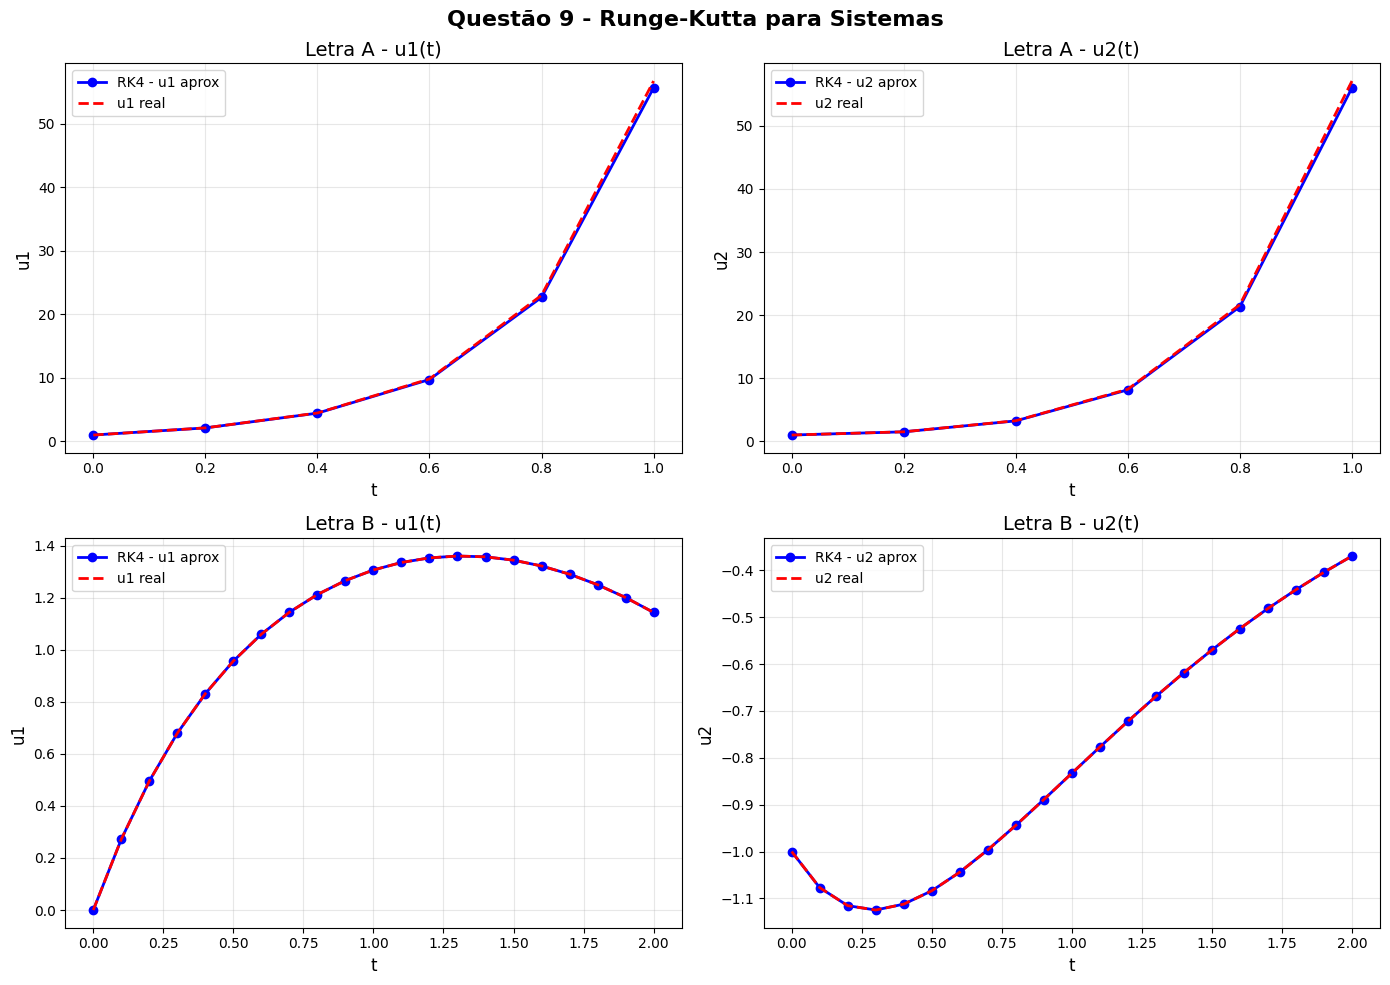

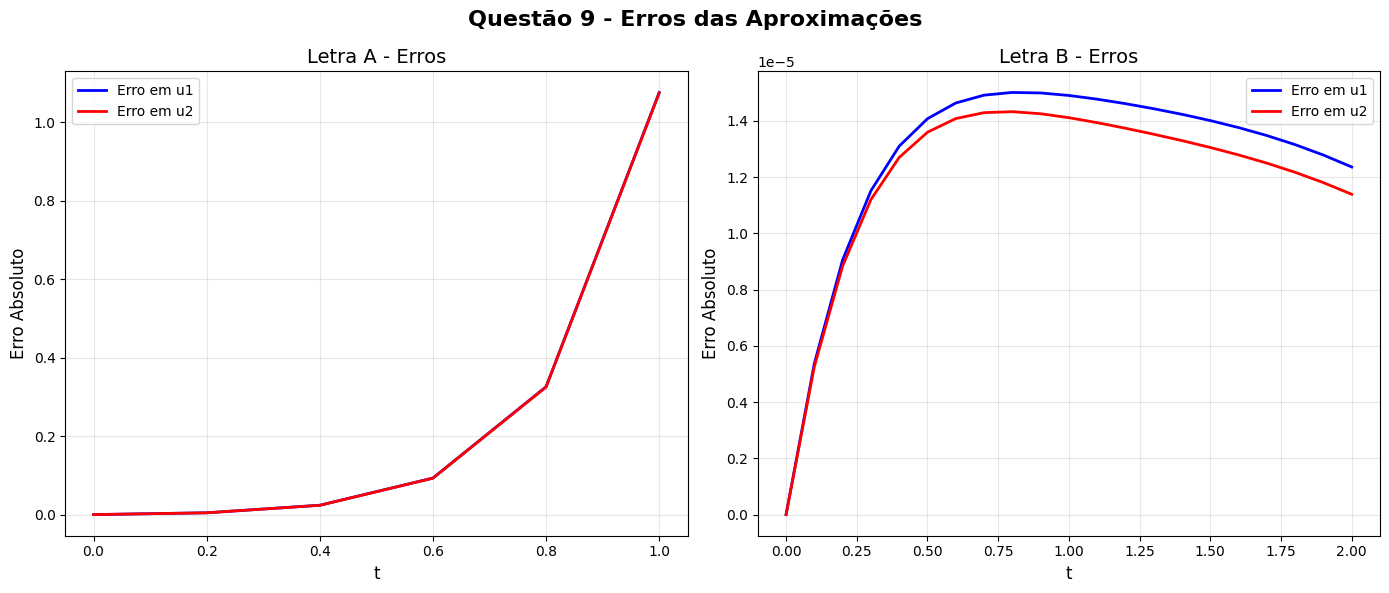

RESUMO FINAL

Letra A - Erro máximo:
  Erro em u1: 1.0763017773
  Erro em u2: 1.0748591339

Letra B - Erro máximo:
  Erro em u1: 0.0000150097
  Erro em u2: 0.0000143262


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_system_2d(f1, f2, t0, u1_0, u2_0, h, t_end):
    """
    Método de Runge-Kutta de 4ª ordem para sistemas de 2 EDOs
    """
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        
        # Estágios k1
        k1_1 = f1(t_curr, u1_curr, u2_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr)
        
        # Estágios k2
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        
        # Estágios k3
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        
        # Estágios k4
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        
        # Atualização
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        t[i+1] = t_curr + h
    
    return t, u1, u2

 
# LETRA A

def f9a1(t, u1, u2):
    """u1' = 3u1 + 2u2 - (2t^2 + 1)e^(2t)"""
    return 3*u1 + 2*u2 - (2*t**2 + 1)*np.exp(2*t)

def f9a2(t, u1, u2):
    """u2' = 4u1 + u2 + (t^2 + 2t - 4)e^(2t)"""
    return 4*u1 + u2 + (t**2 + 2*t - 4)*np.exp(2*t)

def sol9a1(t):
    """Solução real para u1(t)"""
    return (1/3)*np.exp(5*t) - (1/3)*np.exp(-t) + np.exp(2*t)

def sol9a2(t):
    """Solução real para u2(t)"""
    return (1/3)*np.exp(5*t) + (2/3)*np.exp(-t) + t**2*np.exp(2*t)

# Parâmetros da Letra A
t0_a, u1_0_a, u2_0_a, h_a, t_end_a = 0, 1, 1, 0.2, 1

# Executar RK4 para a Letra A
t_a, u1_a, u2_a = rk4_system_2d(f9a1, f9a2, t0_a, u1_0_a, u2_0_a, h_a, t_end_a)

# Calcular soluções reais para comparação
u1_real_a = sol9a1(t_a)
u2_real_a = sol9a2(t_a)

# LETRA B

def f9b1(t, u1, u2):
    """u1' = -4u1 - 2u2 + cos(t) + 4sin(t)"""
    return -4*u1 - 2*u2 + np.cos(t) + 4*np.sin(t)

def f9b2(t, u1, u2):
    """u2' = 3u1 + u2 - 3sin(t)"""
    return 3*u1 + u2 - 3*np.sin(t)

def sol9b1(t):
    """Solução real para u1(t)"""
    return 2*np.exp(-t) - 2*np.exp(-2*t) + np.sin(t)

def sol9b2(t):
    """Solução real para u2(t)"""
    return -3*np.exp(-t) + 2*np.exp(-2*t)

# Parâmetros da Letra B
t0_b, u1_0_b, u2_0_b, h_b, t_end_b = 0, 0, -1, 0.1, 2

# Executar RK4 para a Letra B
t_b, u1_b, u2_b = rk4_system_2d(f9b1, f9b2, t0_b, u1_0_b, u2_0_b, h_b, t_end_b)

# Calcular soluções reais para comparação
u1_real_b = sol9b1(t_b)
u2_real_b = sol9b2(t_b)

# IMPRESSÃO DOS RESULTADOS


print("QUESTÃO 9 - RUNGE-KUTTA PARA SISTEMAS")


# ----- Letra A -----
print("LETRA A")

print("\nSistema:")
print("u1' = 3u1 + 2u2 - (2t^2 + 1)e^(2t),  u1(0) = 1")
print("u2' = 4u1 + u2 + (t^2 + 2t - 4)e^(2t),  u2(0) = 1")
print(f"\nIntervalo: 0 <= t <= 1,  h = {h_a}")

print("t\t\tu1 (aprox)\t\tu1 (real)\t\tu2 (aprox)\t\tu2 (real)")

for i in range(len(t_a)):
    print(f"{t_a[i]:.2f}\t\t{u1_a[i]:.10f}\t{u1_real_a[i]:.10f}\t{u2_a[i]:.10f}\t{u2_real_a[i]:.10f}")

# Calcular erros para Letra A
erro_u1_a = np.max(np.abs(u1_a - u1_real_a))
erro_u2_a = np.max(np.abs(u2_a - u2_real_a))
print("\nErro máximo (u1): {:.10f}".format(erro_u1_a))
print("Erro máximo (u2): {:.10f}".format(erro_u2_a))

# ----- Letra B -----

print("LETRA B")

print("\nSistema:")
print("u1' = -4u1 - 2u2 + cos(t) + 4sin(t),  u1(0) = 0")
print("u2' = 3u1 + u2 - 3sin(t),  u2(0) = -1")
print(f"\nIntervalo: 0 <= t <= 2,  h = {h_b}")

print("t\t\tu1 (aprox)\t\tu1 (real)\t\tu2 (aprox)\t\tu2 (real)")

for i in range(len(t_b)):
    print(f"{t_b[i]:.2f}\t\t{u1_b[i]:.10f}\t{u1_real_b[i]:.10f}\t{u2_b[i]:.10f}\t{u2_real_b[i]:.10f}")

# Calcular erros para Letra B
erro_u1_b = np.max(np.abs(u1_b - u1_real_b))
erro_u2_b = np.max(np.abs(u2_b - u2_real_b))
print("\nErro máximo (u1): {:.10f}".format(erro_u1_b))
print("Erro máximo (u2): {:.10f}".format(erro_u2_b))

# GRÁFICOS

plt.figure(figsize=(14, 10))

# ----- Letra A - u1 -----
plt.subplot(2, 2, 1)
plt.plot(t_a, u1_a, 'bo-', linewidth=2, markersize=6, label='RK4 - u1 aprox')
plt.plot(t_a, u1_real_a, 'r--', linewidth=2, label='u1 real')
plt.xlabel('t', fontsize=12)
plt.ylabel('u1', fontsize=12)
plt.title('Letra A - u1(t)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# ----- Letra A - u2 -----
plt.subplot(2, 2, 2)
plt.plot(t_a, u2_a, 'bo-', linewidth=2, markersize=6, label='RK4 - u2 aprox')
plt.plot(t_a, u2_real_a, 'r--', linewidth=2, label='u2 real')
plt.xlabel('t', fontsize=12)
plt.ylabel('u2', fontsize=12)
plt.title('Letra A - u2(t)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# ----- Letra B - u1 -----
plt.subplot(2, 2, 3)
plt.plot(t_b, u1_b, 'bo-', linewidth=2, markersize=6, label='RK4 - u1 aprox')
plt.plot(t_b, u1_real_b, 'r--', linewidth=2, label='u1 real')
plt.xlabel('t', fontsize=12)
plt.ylabel('u1', fontsize=12)
plt.title('Letra B - u1(t)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# ----- Letra B - u2 -----
plt.subplot(2, 2, 4)
plt.plot(t_b, u2_b, 'bo-', linewidth=2, markersize=6, label='RK4 - u2 aprox')
plt.plot(t_b, u2_real_b, 'r--', linewidth=2, label='u2 real')
plt.xlabel('t', fontsize=12)
plt.ylabel('u2', fontsize=12)
plt.title('Letra B - u2(t)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.suptitle('Questão 9 - Runge-Kutta para Sistemas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# GRÁFICO DOS ERROS

plt.figure(figsize=(14, 6))

# Erros da Letra A
plt.subplot(1, 2, 1)
plt.plot(t_a, np.abs(u1_a - u1_real_a), 'b-', linewidth=2, label='Erro em u1')
plt.plot(t_a, np.abs(u2_a - u2_real_a), 'r-', linewidth=2, label='Erro em u2')
plt.xlabel('t', fontsize=12)
plt.ylabel('Erro Absoluto', fontsize=12)
plt.title('Letra A - Erros', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Erros da Letra B
plt.subplot(1, 2, 2)
plt.plot(t_b, np.abs(u1_b - u1_real_b), 'b-', linewidth=2, label='Erro em u1')
plt.plot(t_b, np.abs(u2_b - u2_real_b), 'r-', linewidth=2, label='Erro em u2')
plt.xlabel('t', fontsize=12)
plt.ylabel('Erro Absoluto', fontsize=12)
plt.title('Letra B - Erros', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.suptitle('Questão 9 - Erros das Aproximações', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# RESUMO FINAL

print("RESUMO FINAL")

print("\nLetra A - Erro máximo:")
print(f"  Erro em u1: {erro_u1_a:.10f}")
print(f"  Erro em u2: {erro_u2_a:.10f}")
print("\nLetra B - Erro máximo:")
print(f"  Erro em u1: {erro_u1_b:.10f}")
print(f"  Erro em u2: {erro_u2_b:.10f}")